In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

import warnings
warnings.simplefilter("ignore")

# Lecture 18

# Comparing Two Samples

In [2]:
births = Table.read_table('baby.csv')

In [3]:
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


Today we have a dataset on babies. 

In this data set, we have: 
* the weight of the babies when born in ounces
* the number of gestational days
* the age of the mother
* the height of the mother in inche
* the weight of the monther in pounds
* and whether the mother was a smoker

Today we will focus on birth weight and if the mother smoked. 

We are interested in comparing the birth weights (a numeric value) for the two different groups (a categorical variable - mothers who smoked or not)

In [4]:
# Make a separate table of the data we are interested in
smoking_and_birthweight = births.select('Maternal Smoker', 'Birth Weight')

In [5]:
# We can look to see how many samples we have in each group. 
smoking_and_birthweight.group('Maternal Smoker')

Maternal Smoker,count
False,715
True,459


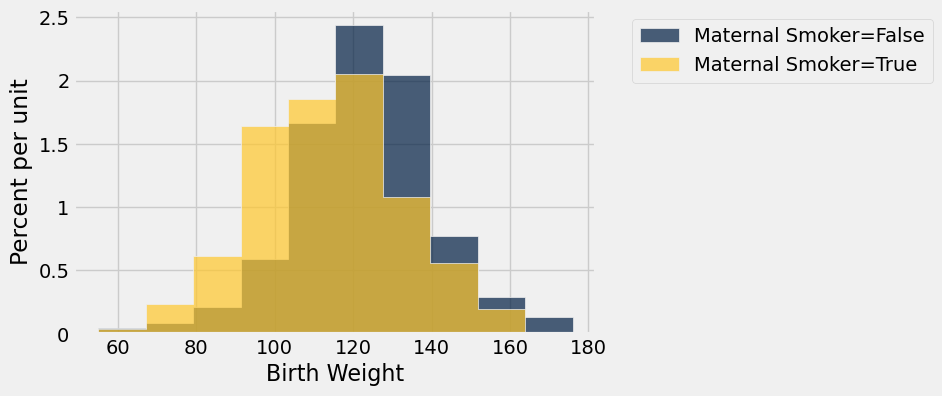

In [6]:
# Let's look at the distribution of birthweights for both groups. 
smoking_and_birthweight.hist('Birth Weight', group='Maternal Smoker')

What do we see? 

It looks like the smoker's birthweight might be slightly lower, but it is hard to see exactly. 

Is this difference just by chance.

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>

# Test Statistic

[Question] What values of our statistic are in favor of the alternative: positive or negative?

* Group A: non-smokers
* Group B: smokers

* Statistic: Difference between average weights  
Group B average - Group A average  


In [7]:
means_table = smoking_and_birthweight.group('Maternal Smoker', np.average)
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


In [8]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

Let's put this into a function. 

Note, this function is very generic, so that we could use this same function with other columns in our data set, or a completely other data set and problem. 

In [9]:
def difference_of_means(table, numeric_label, category_label):
    """
    Takes: 
       - name of table
       - column label of numerical variable
       - column label of categorical variable
       
    Returns: Difference of means of the two groups
    """
    
    #table with the two relevant columns
    reduced = table.select(numeric_label, category_label)  
    
    # table containing group means
    means_table = reduced.group(category_label, np.average)
    
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)

In [10]:
difference_of_means(births, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

How do we actually do the simulation?  

Previously we were sampling from theoretical distribution or sample from the entire population. 
This case is new. 

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>

# Random Permutation (Shuffling)

In [11]:
staff = Table().with_columns(
    'Names', make_array('Jim', 'Pam', 'Dwight', 'Michael'),
    'Ages', make_array(29, 28, 34, 41)
)

In [12]:
# Sample sometimes has repeats 
staff.sample()

Names,Ages
Michael,41
Jim,29
Dwight,34
Pam,28


In [13]:
# Avoids duplicates (unique order) 
staff.sample(with_replacement = False)

Names,Ages
Pam,28
Jim,29
Michael,41
Dwight,34


In [14]:
# In our case, we only want to shuffle the categories
staff.sample(with_replacement = False).column('Names')

array(['Michael', 'Pam', 'Dwight', 'Jim'],
      dtype='<U7')

In [15]:
# We can add this into the table
staff.with_column('Shuffled', staff.sample(with_replacement = False).column(0))

Names,Ages,Shuffled
Jim,29,Jim
Pam,28,Dwight
Dwight,34,Pam
Michael,41,Michael


<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>

# Simulation Under Null Hypothesis

In [16]:
smoking_and_birthweight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [17]:
# Get a shuffle of the labels 
shuffled_labels = smoking_and_birthweight.sample(
    with_replacement=False).column('Maternal Smoker')

In [18]:
# Create a new table with original numeric, original categories, and shuffled labels
original_and_shuffled = smoking_and_birthweight.with_column(
    'Shuffled Label', shuffled_labels
)

In [19]:
# Rerun last two cells, last column changes
original_and_shuffled

Maternal Smoker,Birth Weight,Shuffled Label
False,120,False
False,113,True
True,128,True
True,108,True
False,136,True
False,138,False
False,132,False
False,120,False
True,143,True
False,140,True


In [20]:
# Calculate simulated test statistic 
difference_of_means(original_and_shuffled, 'Birth Weight', 'Shuffled Label')

1.039916510504753

In [21]:
# Calculate the observed statistic
difference_of_means(original_and_shuffled, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

Now we can do our normal process.  

We are going to make this into a function that will do the simulate and calculate the test statistic

# Permutation Test

In [22]:
def one_simulated_difference(table, numeric_label, category_label):
    """
    Takes: 
       - name of table
       - column label of numerical variable
       - column label of categorical variable
       
    Returns: Difference of means of the two groups
    """
    
    # array of shuffled labels
    shuffled_labels = table.sample(with_replacement = False).column(category_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(numeric_label).with_column(
        'Shuffled Label', shuffled_labels)
    
    return difference_of_means(
        shuffled_table, numeric_label, 'Shuffled Label')   

In [23]:
one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')

-1.9649740237975521

Final step, let's do this many, many times.

This code does take a bit longer to run, so we will only do 2500 times in class.  Try with 5000 or 10000 on your own. 

In [24]:
differences = make_array()

for i in np.arange(2500):
    new_difference = one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')
    differences = np.append(differences, new_difference)

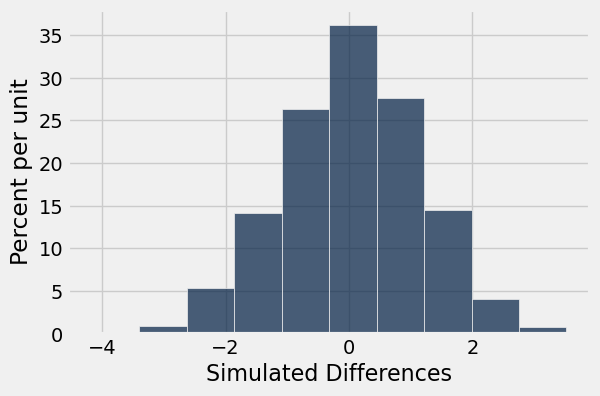

In [25]:
diff_tbl = Table().with_column('Simulated Differences', differences)
diff_tbl.hist()
# # Plotting details; ignore this code
# plots.ylim(-0.02, 0.36)
# plots.scatter(observed_difference, 0, color='red', s=30);

# Uncomment to add in the observed difference

The simulated difference seems to be simulated at 0 which makes sense.  What we are looking at is the spread, how large a difference is possible?

With out even doing the calculation, by inspection, we can estimate the p-value is going to be 0. 

Conclude that the data is consistent with the alternative: babies of smokers weigh less than babies of non-smokers. 

In [26]:
# Calculate the p-value 
#  What percentage of the histogram is to the left of the observed. 
# Using the approach from last time

np.count_nonzero(differences <= observed_difference) / 2500

0.0

In [27]:
# Another way to calculate the p-value 

diff_tbl.where(
    'Simulated Differences', 
    are.below(observed_difference)
).num_rows / 2500

0.0

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>